# Black Friday Dataset EDA And Feature Engineering
## Cleaning and preparing the data for model training

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# importing the train dataset
df_train = pd.read_csv('Datasets/train.csv')
df_train.shape

(550068, 12)

In [3]:
# importing the test dataset
df_test = pd.read_csv('Datasets/test.csv')
df_test.shape

(233599, 11)

In [4]:
# Merge train and test dataset
df = pd.concat([df_train, df_test])
df.shape

(783667, 12)

In [5]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
233594,1006036,P00118942,F,26-35,15,B,4+,1,8,NaN,NaN,NaN
233595,1006036,P00254642,F,26-35,15,B,4+,1,5,8.0,NaN,NaN
233596,1006036,P00031842,F,26-35,15,B,4+,1,1,5.0,12.0,NaN
233597,1006037,P00124742,F,46-50,1,C,4+,0,10,16.0,NaN,NaN


## Basics

In [6]:
# Basic
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 783667 entries, 0 to 233598
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 77.7+ MB


In [7]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [8]:
# Drop user ID column 
df.drop('User_ID', axis=1, inplace=True)

In [9]:
df.shape

(783667, 11)

In [10]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


## Handling Categorical variables
Categorical variables in the dataset
1. Gender
2. Age
3. City_Category

In [11]:
# Handling categorical feature 'Gender'
df['Gender'] = df['Gender'].map({'F':0, 'M':1})

In [12]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


Here, **F - 0** and **M - 1**

In [13]:
# Handling categorical feature 'Age'
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [14]:
df['Age'] = df['Age'].map({'0-17':1, '18-25':2, '26-35':3, '36-45':4, '46-50':5, '51-55':6, '55+':7})

In [15]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0


Here, **1** - '0-17', **2** - '18-25', **3** - '26-35', **4** - '36-45', **5** - '46-50', **6** - '51-55', **7** - '55+'

In [16]:
# Handling categorical feature 'City_Category'
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [17]:
df_cities = pd.get_dummies(df['City_Category'],drop_first=True)

In [18]:
df_cities.head()

,B,C
0,False,False
1,False,False
2,False,False
3,False,False
4,False,True


In [19]:
df = pd.concat([df, df_cities], axis=1)
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0,False,False
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0,False,False
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0,False,False
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0,False,True


## Handline missing values

In [20]:
df.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
B                                  0
C                                  0
dtype: int64

---

So Product_Category_2, Product_Category_3 and Purchase these are three features that has null values.  
The Purchase column have null values that are from Test data. So ignore that.  
We have to fix only Product_Category_2 and Product_Category_3.

In [21]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [22]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [23]:
mode = df['Product_Category_2'].mode()[0]

In [24]:
df['Product_Category_2'].fillna(mode, inplace=True)

In [25]:
mode = df['Product_Category_3'].mode()[0]

In [26]:
df['Product_Category_3'].fillna(mode, inplace=True)

In [27]:
df.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3                 0
Purchase                      233599
B                                  0
C                                  0
dtype: int64

In [28]:
# Fix this also 
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [29]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '')

In [30]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,A,2,0,3,8.0,16.0,8370.0,False,False
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,0,1,10,A,2,0,12,8.0,16.0,1422.0,False,False
3,P00085442,0,1,10,A,2,0,12,14.0,16.0,1057.0,False,False
4,P00285442,1,7,16,C,4,0,8,8.0,16.0,7969.0,False,True


In [31]:
# Convert 'Stay_In_Current_City_Years' into integer
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 783667 entries, 0 to 233598
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   City_Category               783667 non-null  object 
 5   Stay_In_Current_City_Years  783667 non-null  int64  
 6   Marital_Status              783667 non-null  int64  
 7   Product_Category_1          783667 non-null  int64  
 8   Product_Category_2          783667 non-null  float64
 9   Product_Category_3          783667 non-null  float64
 10  Purchase                    550068 non-null  float64
 11  B                           783667 non-null  bool   
 12  C                           783667 non-null  bool   
dtypes: bool(2), float64

## Visualization

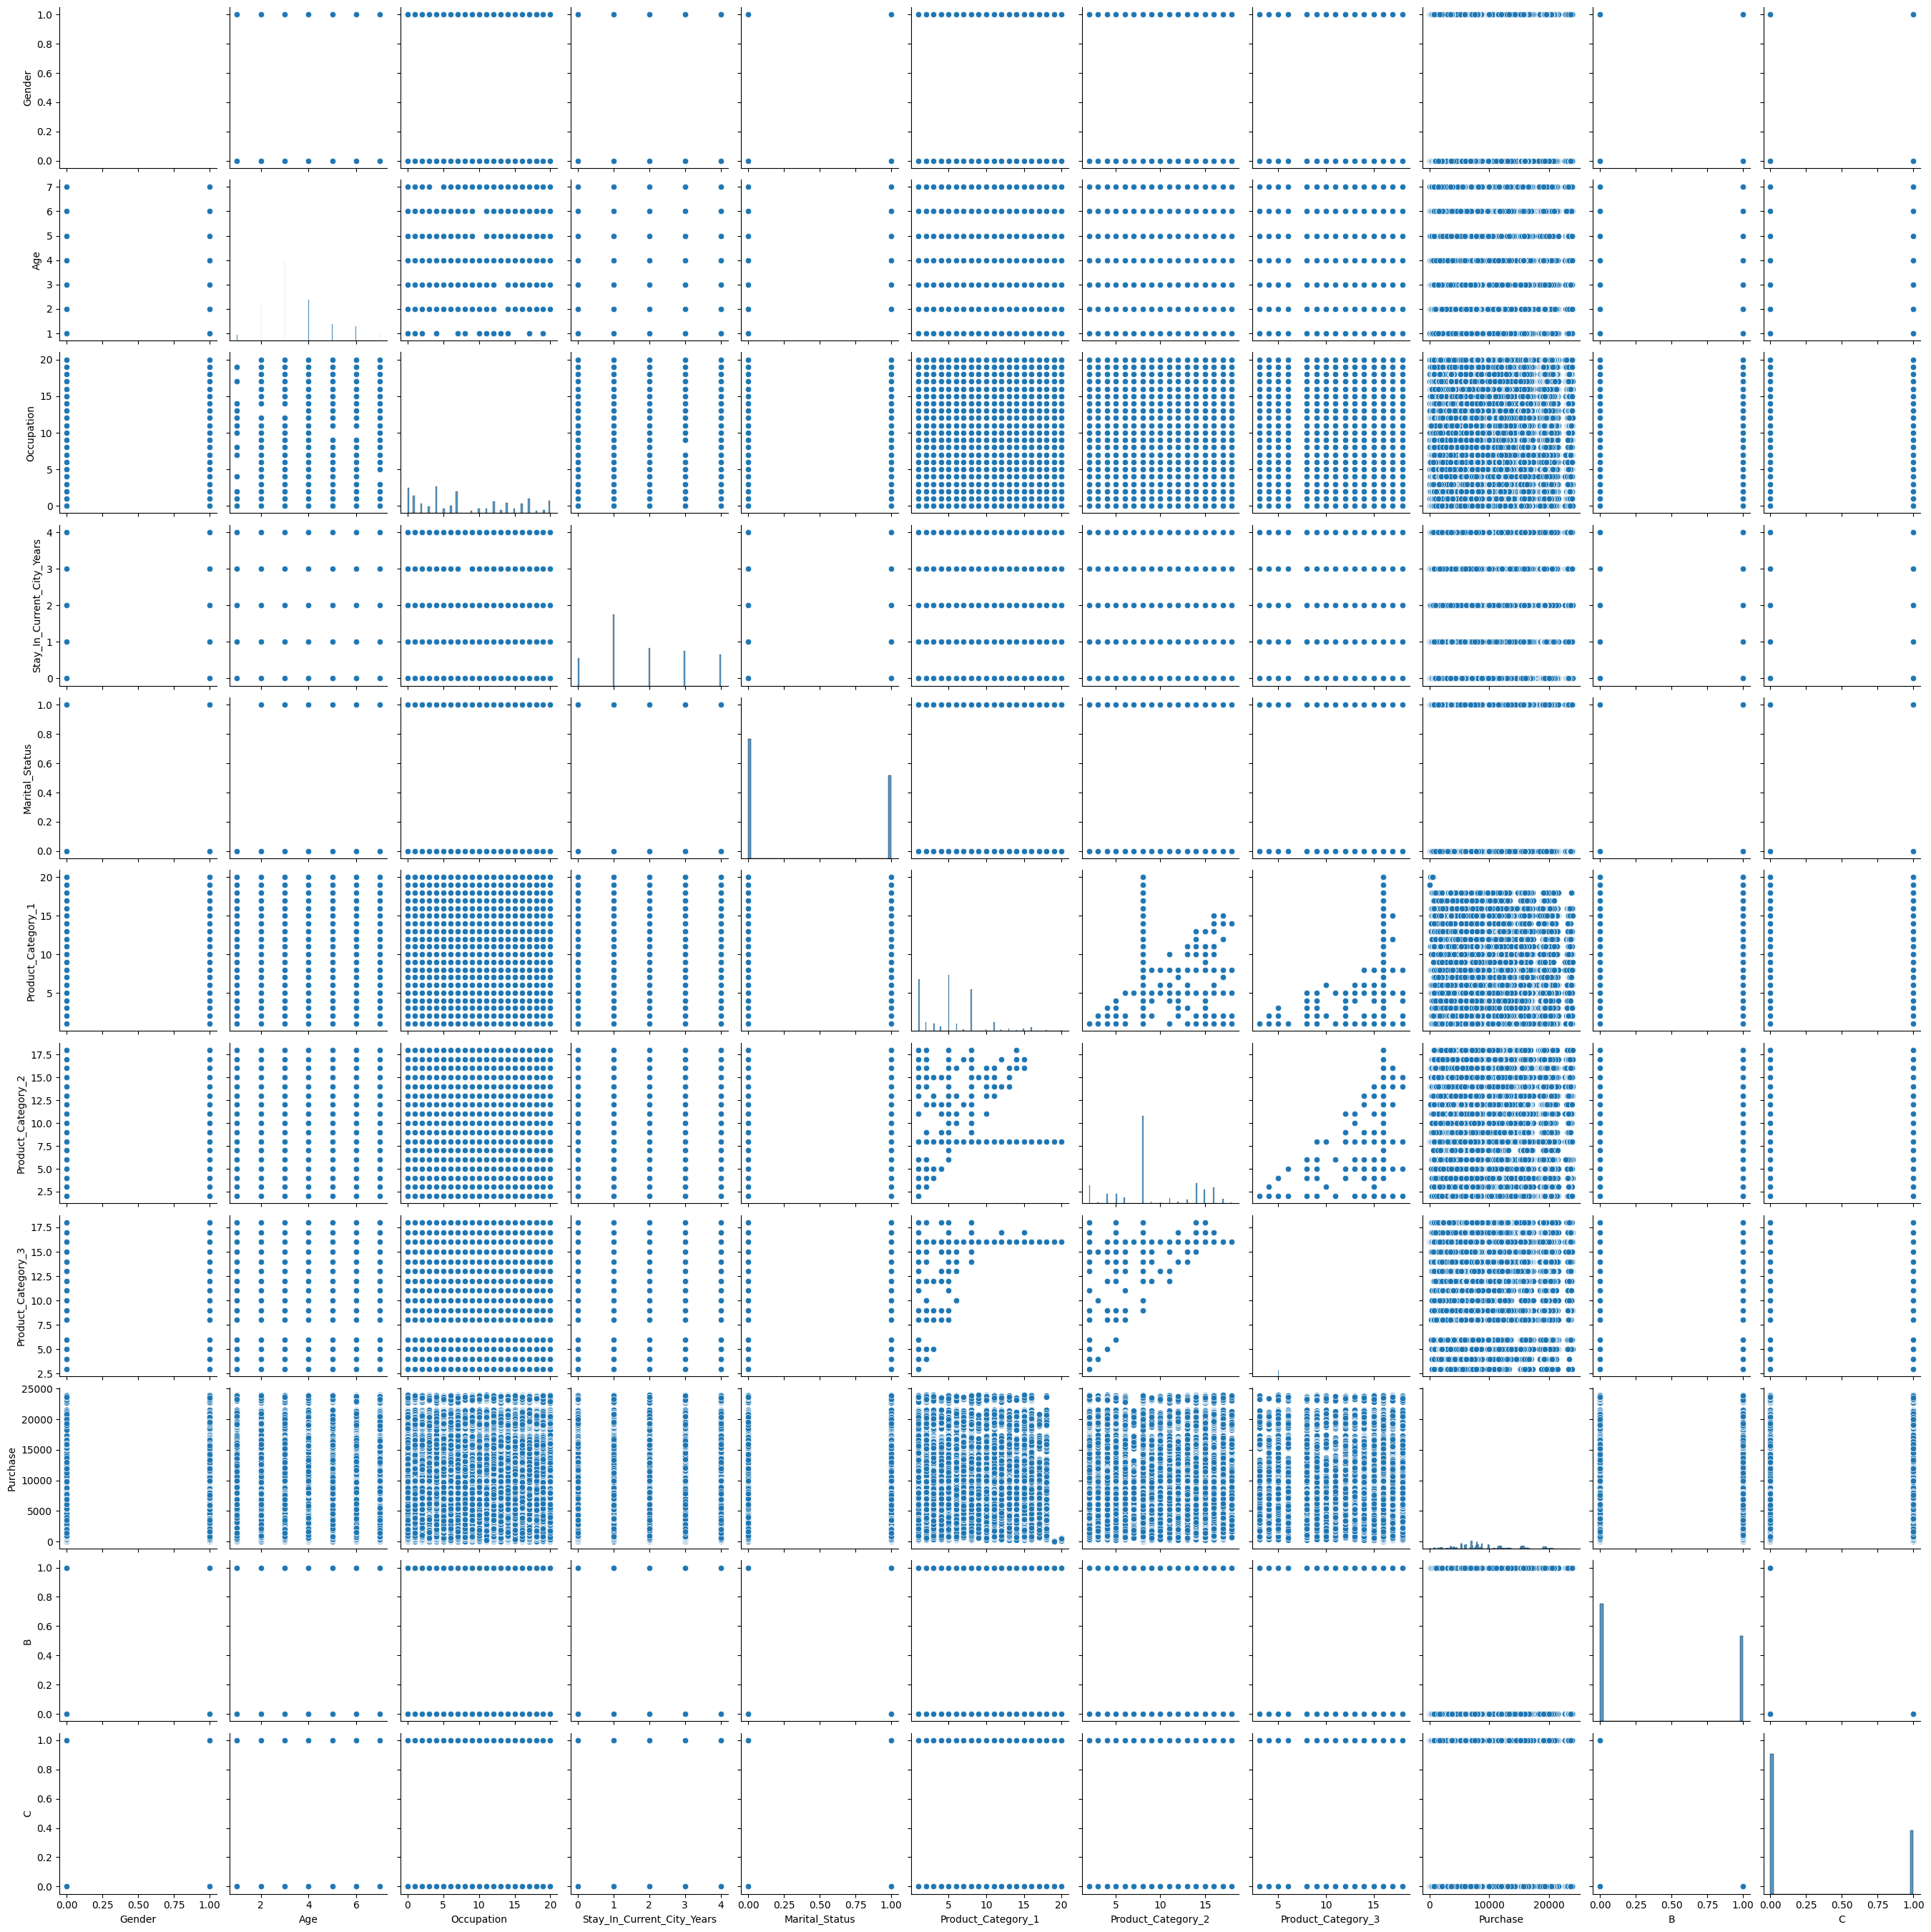

In [33]:
# Visualization
sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Purchase'>

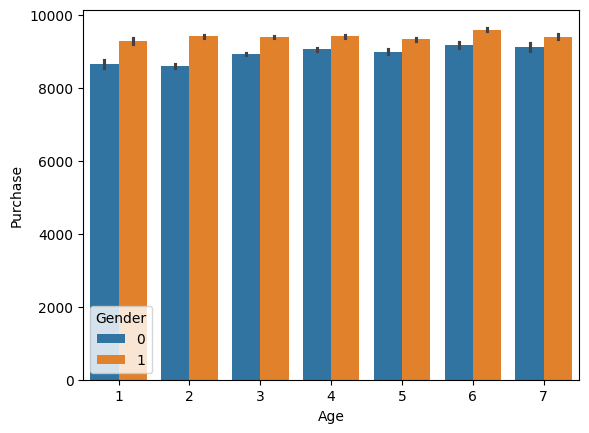

In [34]:
# Age vs Purchase
sns.barplot(data=df, x='Age', y='Purchase', hue='Gender')

In [35]:
# Occupation vs Purchase
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

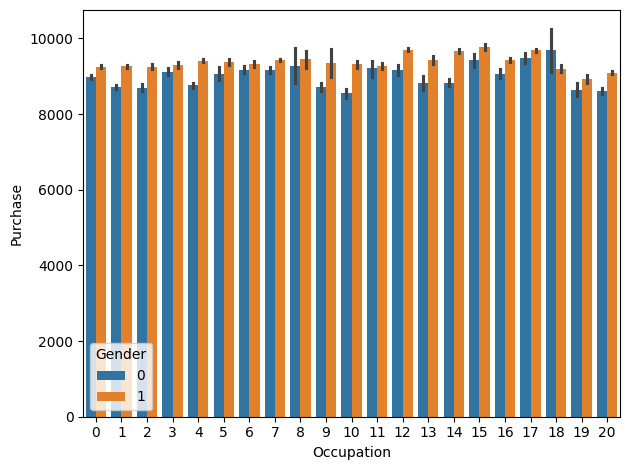

In [36]:
sns.barplot(data=df, x='Occupation', y='Purchase', hue='Gender')
plt.tight_layout()
plt.show()

### Gender

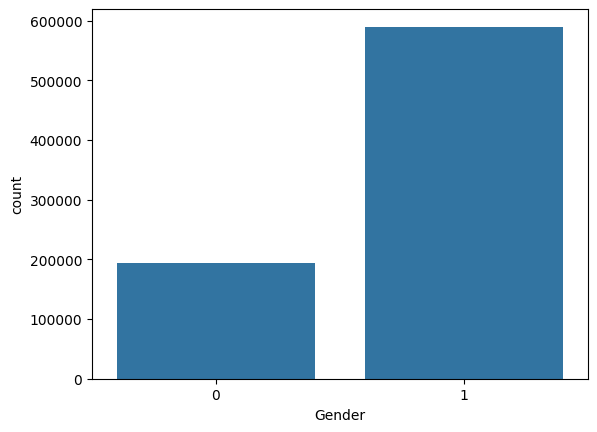

In [86]:
sns.countplot(data=df, x='Gender')
plt.show()

In [39]:
df['Gender'].value_counts(normalize=True)*100

Gender
1    75.291036
0    24.708964
Name: proportion, dtype: float64

F - 0 and M - 1  
Where F - 24% and M - 75%  
There are more males than females

### Marital status

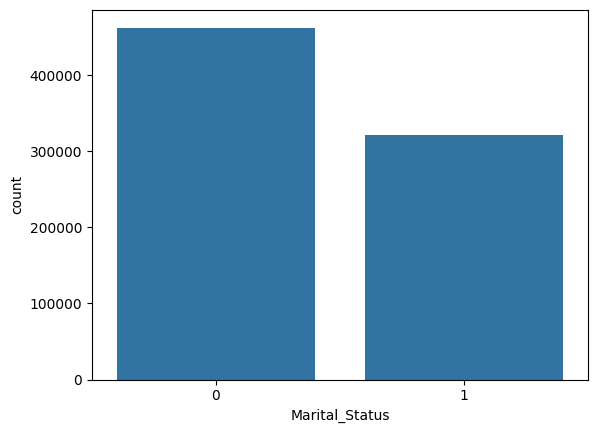

In [40]:
sns.countplot(data=df, x=df['Marital_Status'])
plt.show()

In [43]:
df['Marital_Status'].value_counts(normalize=True)*100

Marital_Status
0    59.022263
1    40.977737
Name: proportion, dtype: float64

So 0 - unmarried  ans 1 - married.  (Assumption)  
So there are more people who are unmarried.

In [44]:
df.groupby('Marital_Status')['Purchase'].mean()

Marital_Status
0    9265.907619
1    9261.174574
Name: Purchase, dtype: float64

<Axes: xlabel='Marital_Status'>

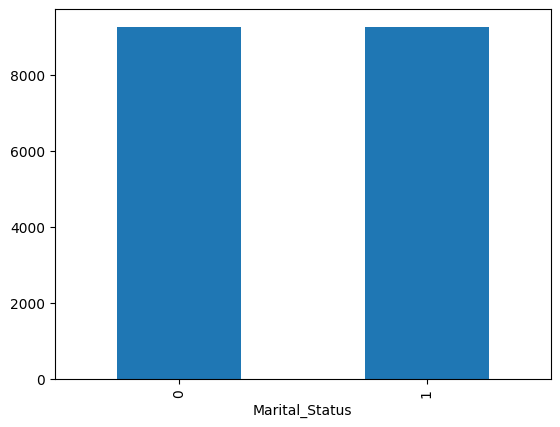

In [45]:
df.groupby('Marital_Status')['Purchase'].mean().plot(kind='bar')

This is intresting that the average purchase from married and unmarried are almost same.

### Occupation

In [52]:
df.Occupation.unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

<Axes: xlabel='Occupation', ylabel='count'>

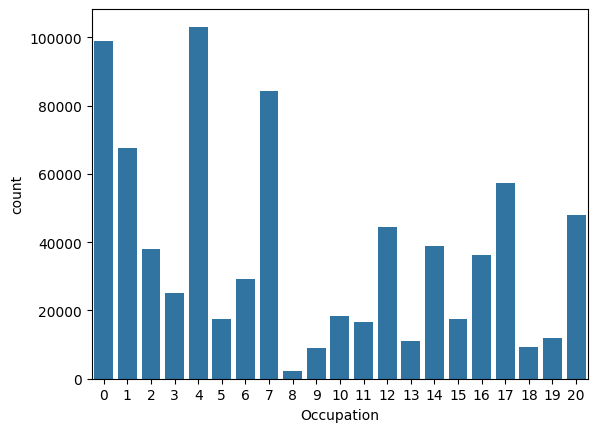

In [54]:
sns.countplot(data=df, x='Occupation')

There are 21 different occupatons. But we dont know its corresponds occupation name so we cant do deep analysis of it.

In [58]:
occu = df.groupby('Occupation')['Purchase'].mean()
occu

Occupation
0     9124.428588
1     8953.193270
2     8952.481683
3     9178.593088
4     9213.980251
5     9333.149298
6     9256.535691
7     9425.728223
8     9532.592497
9     8637.743761
10    8959.355375
11    9213.845848
12    9796.640239
13    9306.351061
14    9500.702772
15    9778.891163
16    9394.464349
17    9821.478236
18    9169.655844
19    8710.627231
20    8836.494905
Name: Purchase, dtype: float64

<Axes: xlabel='Occupation'>

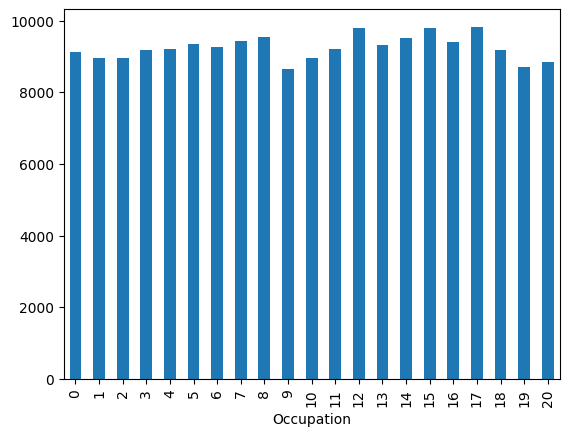

In [59]:
occu.plot(kind='bar')

Each occupation people have spend nearly same amount of money.

In [61]:
occu.mean()

np.float64(9242.711112995636)

### City_Category

<Axes: xlabel='City_Category', ylabel='count'>

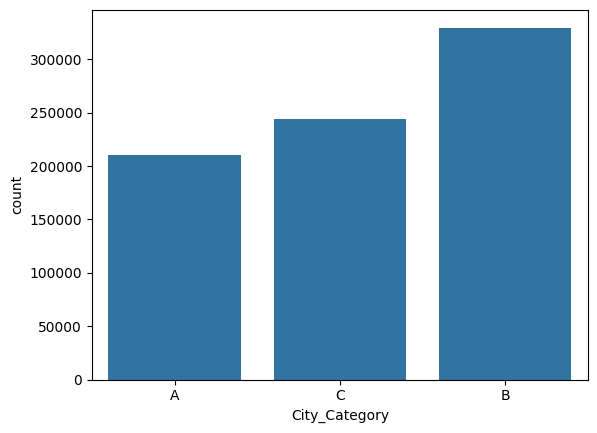

In [63]:
sns.countplot(data=df, x='City_Category')

So from above we can see that the city category B has most customers and then C and lowest has A.

In [66]:
cc = df.groupby('City_Category')['Purchase'].mean()
cc

City_Category
A    8911.939216
B    9151.300563
C    9719.920993
Name: Purchase, dtype: float64

<Axes: xlabel='City_Category'>

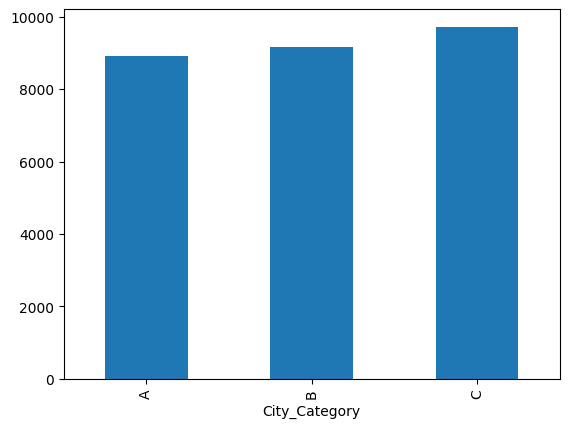

In [67]:
cc.plot(kind='bar')

Now we can say that the City category 'C' spend more money than 'B' and 'B' than 'A'.

### Stay_In_Current_City_Years

In [70]:
df['Stay_In_Current_City_Years'].unique()

array([2, 4, 3, 1, 0])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

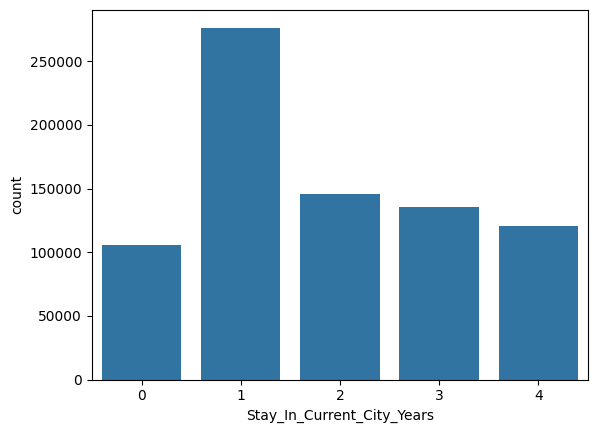

In [71]:
sns.countplot(data=df, x='Stay_In_Current_City_Years')

### Age

In [73]:
df.Age.unique()

array([1, 7, 3, 5, 6, 4, 2])

Here, **1** - '0-17', **2** - '18-25', **3** - '26-35', **4** - '36-45', **5** - '46-50', **6** - '51-55', **7** - '55+'

<Axes: xlabel='Age', ylabel='count'>

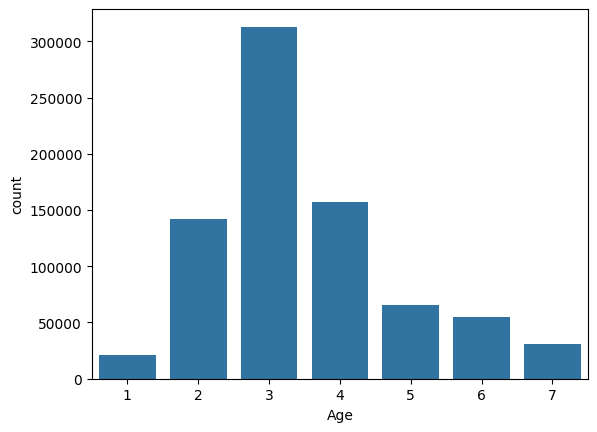

In [75]:
sns.countplot(data=df, x='Age')

So we can say that there are more peoples from age group 26-35

In [78]:
ap = df.groupby('Age')['Purchase'].mean()
ap

Age
1    8933.464640
2    9169.663606
3    9252.690633
4    9331.350695
5    9208.625697
6    9534.808031
7    9336.280459
Name: Purchase, dtype: float64

<Axes: xlabel='Age'>

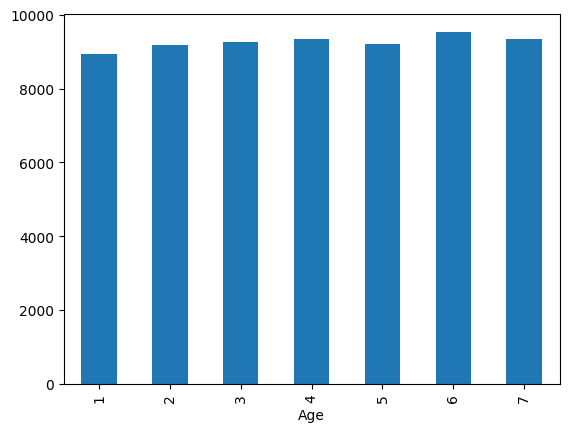

In [79]:
ap.plot(kind='bar')

All age groups spend on an average same amount.  
The 6th age group i.e. 46-50 spend little more.  

<Axes: xlabel='Age'>

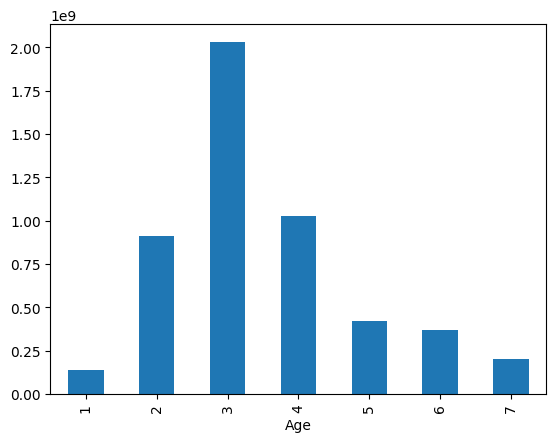

In [81]:
df.groupby('Age')['Purchase'].sum().plot(kind='bar')

While average spending is similar across ages, the total revenue is heavily concentrated in the 26-35 age group. This indicates that this demographic represents the largest volume of customers in the dataset.